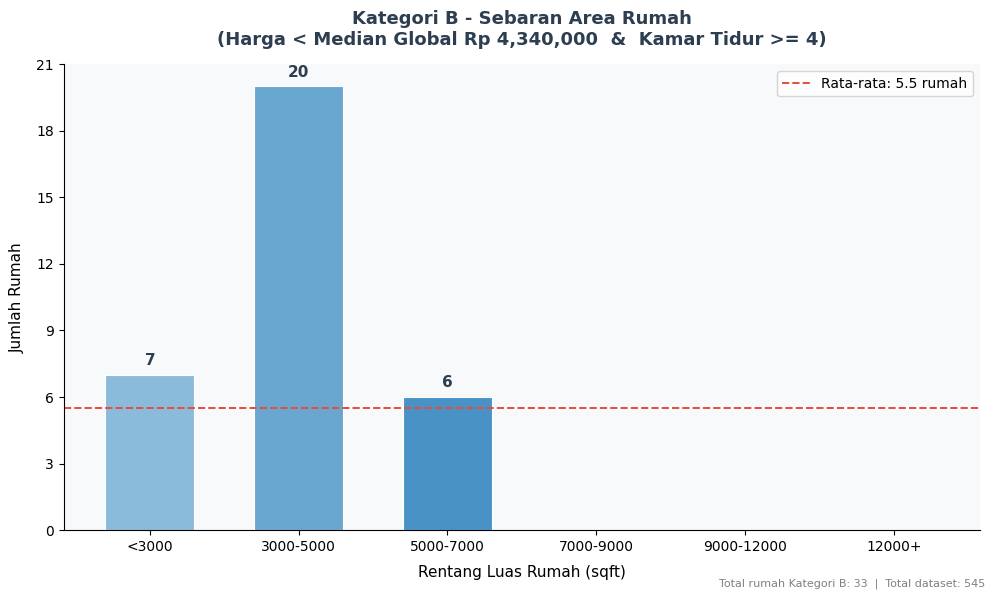

Grafik disimpan: kategori_b_bar_chart.png


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 1. Load & Filter Data
df = pd.read_csv("Kelas C_Housing.csv")

median_price = df["price"].median()

# Kategori B: harga < median global DAN bedrooms >= 4
df_b = df[(df["price"] < median_price) & (df["bedrooms"] >= 4)].copy()

# 2. Buat Kolom Area Range
bins   = [0, 3000, 5000, 7000, 9000, 12000, float("inf")]
labels = ["<3000", "3000-5000", "5000-7000", "7000-9000", "9000-12000", "12000+"]

df_b["area_range"] = pd.cut(df_b["area"], bins=bins, labels=labels, right=True)

area_counts = (
    df_b["area_range"]
    .value_counts()
    .reindex(labels)
    .fillna(0)
    .astype(int)
    .reset_index()
)
area_counts.columns = ["area_range", "jumlah_rumah"]

# 3. Warna Palette
palette = sns.color_palette("Blues_d", n_colors=len(labels))

# 4. Buat Figur dengan Pendekatan Objek
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
ax = axes  # alias agar mudah digabung ke subplot grid nanti (axes[baris, kolom])

# 5. Plot Bar Chart
bars = ax.bar(
    area_counts["area_range"],
    area_counts["jumlah_rumah"],
    color=palette,
    edgecolor="white",
    linewidth=0.8,
    width=0.6,
)

# Label nilai di atas tiap bar
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.3,
            str(int(h)),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color="#2c3e50",
        )

# 6. Garis rata-rata sebagai referensi
mean_val = area_counts["jumlah_rumah"].mean()
ax.axhline(
    mean_val,
    color="#e74c3c",
    linestyle="--",
    linewidth=1.4,
    label="Rata-rata: {:.1f} rumah".format(mean_val),
)

# 7. Styling
ax.set_title(
    "Kategori B - Sebaran Area Rumah\n"
    "(Harga < Median Global Rp {:,.0f}  &  Kamar Tidur >= 4)".format(median_price),
    fontsize=13,
    fontweight="bold",
    color="#2c3e50",
    pad=14,
)
ax.set_xlabel("Rentang Luas Rumah (sqft)", fontsize=11, labelpad=8)
ax.set_ylabel("Jumlah Rumah", fontsize=11, labelpad=8)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(fontsize=10)
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#ffffff")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

# Anotasi info dataset
fig.text(
    0.99, 0.01,
    "Total rumah Kategori B: {}  |  Total dataset: {}".format(len(df_b), len(df)),
    ha="right",
    va="bottom",
    fontsize=8,
    color="gray",
)

plt.tight_layout()
plt.savefig("kategori_b_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik disimpan: kategori_b_bar_chart.png")